# 卷积神经网络特征图可视化

In [4]:
import torch
import numpy as np
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
from utils.readData import read_dataset
from utils.ResNet import ResNet18

### Step 1. 定义特征钩子（Hook）

In [1]:
feature_maps = []

def hook_fn(module, input, output):
    feature_maps.append(output.detach().cpu())

### Step 2. 注册钩子到目标层

In [7]:
# set device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# 加载模型(使用预处理模型，修改最后一层，固定之前的权重)
n_class = 10
model = ResNet18()
"""
ResNet18网络的7x7降采样卷积和池化操作容易丢失一部分信息,
所以在实验中我们将7x7的降采样层和最大池化层去掉,替换为一个3x3的降采样卷积,
同时减小该卷积层的步长和填充大小
"""
model.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1, bias=False)
model.fc = torch.nn.Linear(512, n_class) # 将最后的全连接层改掉
model = model.to(device)
# 使用交叉熵损失函数
criterion = nn.CrossEntropyLoss().to(device)
hook = model.conv1.register_forward_hook(hook_fn)

### Step 3. 前向推理，采集特征图

In [9]:
# 读数据
batch_size = 128
train_loader,valid_loader,test_loader = read_dataset(batch_size=batch_size,pic_path='dataset')
# 选取一张测试图片
import torch
img, _ = next(iter(test_loader))  # 获取一个 batch
input_img = img[0].unsqueeze(0).to(device)  # 取第一张图片

model.eval()
with torch.no_grad():
    _ = model(input_img)

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified


### Step 4. Matplotlib 可视化特征图

d:\miniconda3\envs\torch_cu124\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\miniconda3\envs\torch_cu124\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\miniconda3\envs\torch_cu124\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


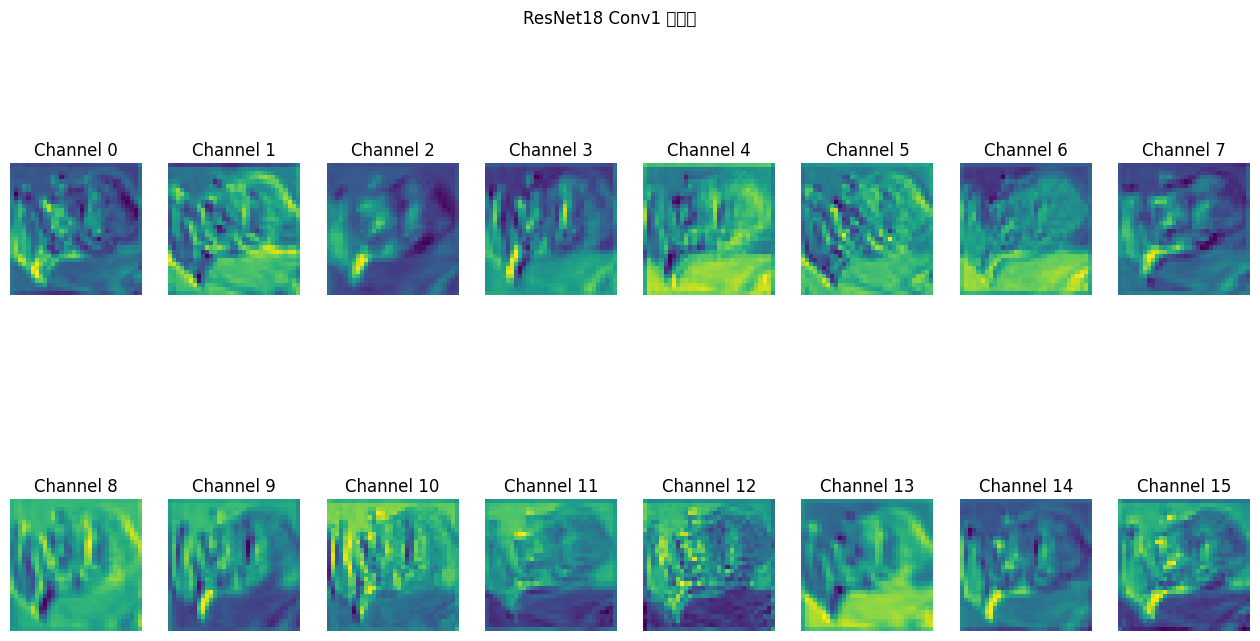

In [11]:
import matplotlib.pyplot as plt

fm = feature_maps[0][0]  # [channel, h, w]
n_channels = fm.shape[0]
plt.figure(figsize=(16, 8))
for i in range(min(n_channels, 16)):  # 可视化前16个通道
    plt.subplot(2, 8, i+1)
    plt.imshow(fm[i], cmap='viridis')
    plt.axis('off')
    plt.title(f'Channel {i}')
plt.suptitle('ResNet18 Conv1 特征图')
plt.show()